# Module 07 Lab - Better Model Evaluation**Objective:** To move beyond simple accuracy and learn how to use more sophisticated and reliable evaluation techniques, including the confusion matrix, precision, recall, and cross-validation.**In this lab, you will write the code to generate and interpret these advanced evaluation metrics.**

## Part 1: Setup and Model TrainingLet's first train a model so we have something to evaluate. We will use the Titanic dataset again to predict survival.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the Titanic dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

# Convert sex into numeric values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Fill missing ages with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Select the model features and target
features = ["Age", "Pclass", "Sex", "Fare"]
target = "Survived"

X = df[features]
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model trained successfully.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Model trained successfully.
Training samples: 712
Testing samples: 179


## Part 2: The Confusion Matrix**Concept:** A confusion matrix gives you a more detailed breakdown of a model's performance than accuracy alone. It's a table that shows you where your model got things right and where it got them wrong.It has four quadrants:*   **True Positives (TP):** Correctly predicted positive (e.g., predicted survival, and they did survive).*   **True Negatives (TN):** Correctly predicted negative (e.g., predicted did not survive, and they did not).*   **False Positives (FP):** Incorrectly predicted positive (e.g., predicted survival, but they did not). Also called a "Type I Error".*   **False Negatives (FN):** Incorrectly predicted negative (e.g., predicted did not survive, but they did). Also called a "Type II Error".

### Task 1: Generate and Plot a Confusion Matrix**Your Task:** Use `confusion_matrix` from `sklearn.metrics` to calculate the matrix and `seaborn.heatmap` to visualize it.

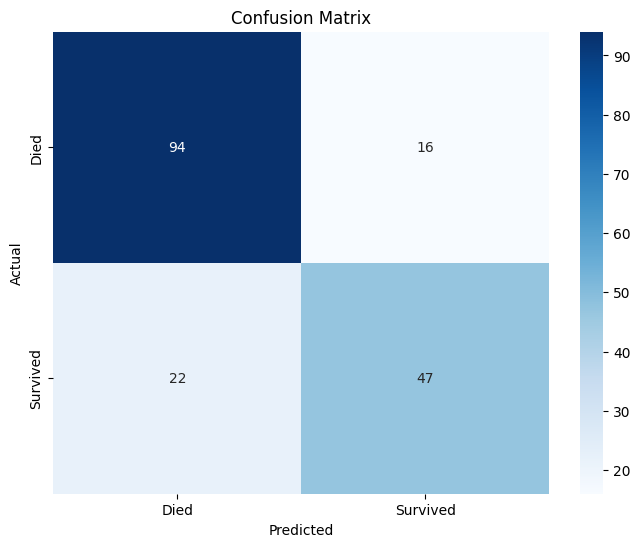

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Died", "Survived"],
    yticklabels=["Died", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Part 3: Precision, Recall, and F1-Score**Concept:** From the confusion matrix, we can calculate more nuanced metrics:*   **Precision:** Of all the times the model predicted **positive**, how often was it correct?     *   Formula: `TP / (TP + FP)`    *   *Use Case:* When the cost of a **False Positive** is high. (e.g., a spam filter; you don't want to incorrectly mark an important email as spam).*   **Recall (Sensitivity):** Of all the actual **positives**, how many did the model correctly identify?    *   Formula: `TP / (TP + FN)`    *   *Use Case:* When the cost of a **False Negative** is high. (e.g., a medical test for a serious disease; you don't want to miss a real case).*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both.

### Task 2: Generate a Classification Report**Your Task:** Use `classification_report` from `sklearn.metrics` to get a summary of these metrics for each class.

In [3]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["Died", "Survived"]
)

# Print precision, recall, F1-score, and accuracy
print(report)

              precision    recall  f1-score   support

        Died       0.81      0.85      0.83       110
    Survived       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



## Part 4: Cross-Validation**Concept:** A single train-test split can be lucky or unlucky. What if, by chance, all the "easy" examples ended up in our test set? Our accuracy score would be misleadingly high.**Cross-Validation (CV)** solves this. It splits the data into multiple "folds" (e.g., 5 or 10). It then trains and evaluates the model multiple times, using a different fold as the test set each time. The final score is the average of the scores from all folds.This gives a much more robust and reliable estimate of the model's true performance.

### Task 3: Perform Cross-Validation**Your Task:** Use `cross_val_score` from `sklearn.model_selection` to perform 5-fold cross-validation on your model.

In [4]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)

# Print the scores
print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2%}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Scores for each fold: [0.7877095  0.78089888 0.78651685 0.7752809  0.80337079]
Average CV Score: 78.68%
Standard Deviation of CV Scores: 0.0094


## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **Describe a real-world scenario where you would care more about a model's Precision than its Recall.**2.  **Describe a real-world scenario where you would care more about a model's Recall than its Precision.**3.  **Why is a cross-validation score generally more trustworthy than a score from a single train-test split?

1․ A spam email filter is a good example of a situation where precision is important: people dislike legitimate emails being classified as spam․

2․ Medical screening tests․ If the goal of a medical screening test is to identify a serious disease‚ then recall is prioritized‚ because the cost of missing a positive case is higher than a false positive on a healthy test․

3․ Cross-validation differs from simply using a single train-test split in that multiple train-test splits are used‚ and their performance is averaged․